# Aula 01 — Dados Sujos no Mundo Real: Missings e Duplicatas

**Semana 06 · Dia 01 (Terça-feira) · SENAI — Visualização de Dados**
Hoje vamos aprender a **identificar e corrigir** os dois problemas mais comuns em bases reais:

1. **Valores ausentes** (NaN, None, NA) — campos vazios onde deveria haver informação
2. **Duplicatas** — registros repetidos por erro de importação ou digitação

A base que usaremos é de **vendas de supermercado** — 250 transações reais. Vamos primeiro explorar os dados originais e depois criar uma versão "suja" para praticar cada técnica de limpeza.

> **Por que praticar com dados sujos artificiais?** Em sala de aula, criamos os problemas propositalmente para entender exatamente o que aconteceu. No mercado de trabalho, os problemas já vêm prontos — e piores.

## Bloco 0 — Setup
O arquivo `base_vendas_supermercado.xlsx` está na pasta `base/`, que fica **ao lado deste notebook**. O caminho `../base/` significa: *"sobe uma pasta e entra na pasta base"*.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import openpyxl

# Caminho relativo: sobe uma pasta (../) e entra em base/
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
df = pd.read_excel("../base/base_vendas_supermercado.xlsx")

print(f"Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"Período das vendas: {df['Data'].min().date()} até {df['Data'].max().date()}")
print()
print("Colunas disponíveis:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

Dataset carregado: 250 linhas x 12 colunas
Período das vendas: 2026-01-01 até 2026-05-05

Colunas disponíveis:
   1. Data
   2. Loja
   3. Cliente
   4. Categoria
   5. Produto
   6. Quantidade
   7. Preço Unitário
   8. Desconto %
   9. Valor Bruto
  10. Valor Desconto
  11. Valor Líquido
  12. Forma de Pagamento


## Explorando a Base

Todo analista tem um "checklist" que roda assim que recebe uma base nova. Vamos rodar o nosso:

| Método | Para que serve |
|---|---|
| `head()` | Ver as primeiras linhas — estrutura e exemplos de valores |
| `info()` | Tipo de dado de cada coluna e quantidade de valores não-nulos |
| `describe()` | Estatísticas das colunas numéricas (média, mínimo, máximo...) |

O `info()` é especialmente útil: ele mostra de cara se alguma coluna tem valores nulos (non-null count menor que o total).

In [ ]:
print("=== Primeiras 5 linhas ===")
print(df.head().to_string())
print()

print("=== Estrutura da base ===")
df.info()
print()

print("=== Estatísticas numéricas ===")
print(df.describe().round(2).to_string())

=== Primeiras 5 linhas ===
        Data           Loja           Cliente   Categoria                Produto  Quantidade  Preço Unitário  Desconto %  Valor Bruto  Valor Desconto  Valor Líquido Forma de Pagamento
0 2026-01-04  Loja Shopping     Cliente Final  Laticínios  Queijo Mussarela 500g           4           23.53        0.00        94.12            0.00          94.12   Vale Alimentação
1 2026-01-04    Loja Centro  Clube Fidelidade   Mercearia     Óleo de Soja 900ml           4            6.97        0.00        27.88            0.00          27.88   Vale Alimentação
2 2026-02-27  Loja Shopping  Clube Fidelidade     Padaria         Pão Francês kg           4           15.84        0.03        63.36            1.90          61.46  Cartão de Crédito
3 2026-01-12     Loja Norte     Cliente Final  Laticínios      Leite Integral 1L           6            6.21        0.03        37.26            1.12          36.14           Dinheiro
4 2026-05-05     Loja Norte  Clube Fidelidade  Laticí

- **250 linhas** — base pequena, mas representativa para aprender
- **Tipos mistos** — colunas de data, texto e números convivem na mesma tabela
- **Valor Líquido** vai de ~R$ 3 a ~R$ 197 — já vemos uma variação grande
- O `info()` mostra **250 non-null** em todas as colunas → a base original está limpa!

## Bloco 1 — Valores Ausentes: O Que São e Como Detectar
> Isso é incomum na vida real. Para praticar as técnicas de limpeza, vamos criar uma versão "suja" no próximo bloco.
#### Por que surgem valores ausentes?<br>
- **Erro de digitação** → operador deixou o campo em branco
- **Sistema não registrou** → integração falhou no momento da venda
- **Dado não se aplica** → campo "Desconto" vazio significa 0%, não informação faltando
- **Coleta incompleta** → cliente não informou e-mail no cadastro

Em pandas, valores ausentes aparecem como **NaN** (*Not a Number*) para números, **None** para objetos, e **NaT** (*Not a Time*) para datas.

In [ ]:
# Criando uma versão "suja" para prática 
np.random.seed(42)           # garante que os resultados sejam iguais sempre
df_sujo = df.copy()          # NOVA BASE!

# 1. Inserir **NaN** em colunas específicas (simula falhas de sistema)
nan_config = {
    'Categoria':          14,   # 14 registros sem categoria
    'Preço Unitário':     12,   # 12 preços não registrados
    'Forma de Pagamento': 10,   # 10 pagamentos sem forma
    'Quantidade':          8,   # 8 quantidades ausentes
}
for coluna, qtd in nan_config.items():
    indices = np.random.choice(df_sujo.index, size=qtd, replace=False)
    df_sujo.loc[indices, coluna] = np.nan

# 2. Inserir duplicatas (simula importação dupla de planilha)
duplicatas = df_sujo.sample(n=12, random_state=7)
df_sujo = pd.concat([df_sujo, duplicatas], ignore_index=True)
df_sujo = df_sujo.sample(frac=1, random_state=3).reset_index(drop=True)

print("=== Visualização: Original VS Sujo ===")
print(f"{'Métrica':<30} {'Original':>10} {'Sujo':>8}")
print("-" * 52)
print(f"{'Linhas':<30} {df.shape[0]:>10} {df_sujo.shape[0]:>8}")
print(f"{'Colunas':<30} {df.shape[1]:>10} {df_sujo.shape[1]:>8}")
print(f"{'Total de NaN':<30} {df.isnull().sum().sum():>10} {df_sujo.isnull().sum().sum():>8}")
print(f"{'Duplicatas':<30} {df.duplicated().sum():>10} {df_sujo.duplicated().sum():>8}")

=== Visualização: Original VS Sujo ===
Métrica                          Original     Sujo
----------------------------------------------------
Linhas                                250      262
Colunas                                12       12
Total de NaN                            0       47
Duplicatas                              0       12


## Detectando Valores Ausentes

O pandas tem dois métodos equivalentes para verificar valores ausentes:
- `isnull()` → retorna `True` onde há NaN
- `isna()` → exatamente a mesma coisa (é um apelido)

A combinação com `.sum()` é o que usamos na prática: conta os True por coluna.

In [19]:
# isnull() retorna True onde há NaN — soma conta os True por coluna
nan_por_coluna = df_sujo.isnull().sum()
print("=== NaN por coluna ===")
print(nan_por_coluna.to_string())

print()
print(f"Total de NaN: {df_sujo.isnull().sum().sum()}")
print(f"Total de linhas com NaN: {df_sujo.isnull().any(axis=1).sum()}")

=== NaN por coluna ===
Data                   0
Loja                   0
Cliente                0
Categoria             16
Produto                0
Quantidade             9
Preço Unitário        12
Desconto %             0
Valor Bruto            0
Valor Desconto         0
Valor Líquido          0
Forma de Pagamento    10

Total de NaN: 47
Total de linhas com NaN: 45


### Percentual de Ausentes

Em vez de contar valores absolutos, é mais informativo calcular **o percentual** de ausentes por coluna.<br>
Isso permite comparar colunas independentemente do tamanho da base.

> **Regra prática:** se uma coluna tem mais de **30% de ausentes**, questione se ela deve ser mantida.

In [21]:
# Percentual de NaN por coluna (só mostra colunas com NaN)
pct_nan = (df_sujo.isnull().sum() / len(df_sujo) * 100).round(1)
pct_nan_filtrado = pct_nan[pct_nan > 0].sort_values(ascending=False)

print("=== Valores Ausentes em % ===")
for coluna, pct in pct_nan_filtrado.items():
    barras = '█' * int(pct / 2)
    print(f"  {coluna:<20} {pct:5.2f}% {barras}")

=== Valores Ausentes em % ===
  Categoria             6.10% ███
  Preço Unitário        4.60% ██
  Forma de Pagamento    3.80% █
  Quantidade            3.40% █


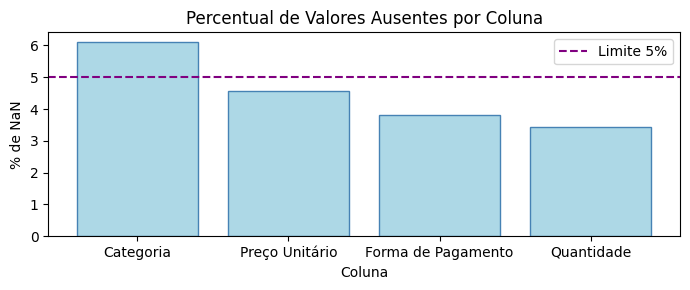

In [55]:
# Gráfico de barras: % de ausentes por coluna
pct_nan = df_sujo.isnull().mean() * 100
pct_nan = pct_nan[pct_nan > 0].sort_values(ascending=False)

plt.figure(figsize=(7, 3))
plt.bar(pct_nan.index, pct_nan.values, color='lightblue', edgecolor='steelblue')
plt.axhline(5, color='purple', linestyle='--', linewidth=1.5, label='Limite 5%')
plt.title('Percentual de Valores Ausentes por Coluna')
plt.xlabel('Coluna')
plt.ylabel('% de NaN')
plt.legend()
plt.tight_layout()
plt.show()

---
### O que este gráfico mostra?
Antes de tratar, entender **por que** os dados estão ausentes é fundamental:
- Se `Forma de Pagamento` está vazia em vendas antigas, pode ser que o sistema de pagamento não registrava esse dado
- Se `Preço Unitário` está vazio em produtos específicos, pode ser erro de importação
- Esse diagnóstico define qual estratégia de tratamento usar

## Bloco 2 — Tratando Valores Ausentes:

Quatro Estratégias - Não existe uma única forma certa de tratar ausentes.

A escolha depende de:<br>
- **Tipo de dado** (numérico, categórico, data)
- **Motivo do ausente** (erro de sistema, dado opcional, etc.)
- **Impacto na análise** (quanto esse campo importa para o que queremos responder)

As estratégias principais são:
| Estratégia | Quando usar |
|---|---|
| `dropna()` | Quando a linha inteira não tem salvação |
| `fillna(valor)` | Quando sabemos o que colocar (ex: 0, "Desconhecido") |
| `fillna(estatística)` | Quando queremos a média, mediana ou moda |
| `ffill()` / `bfill()` | Para séries temporais ou dados ordenados |

### Estratégia 1 — `dropna()`: Remover linhas com NaN

`dropna()` remove qualquer linha que tenha pelo menos um NaN.

> **Cuidado:** se usarmos sem parâmetros em nosso `df_sujo`, perderemos ~44 linhas (registros com NaN em qualquer coluna).<br>
> Às vezes vale a pena ser mais seletivo: remover apenas linhas com NaN em colunas críticas.

**Parâmetros úteis:**
- `subset=['col1', 'col2']` — só remove se NaN estiver nessas colunas
- `how='all'` — só remove se **todas** as colunas estiverem vazias
- `thresh=N` — remove se tiver menos de N valores não-nulos

In [57]:
# Quantas linhas perderíamos com dropna() padrão?
antes = len(df_sujo)
df_sem_nan = df_sujo.dropna()
depois = len(df_sem_nan)
print(f"Antes : {antes} linhas")
print(f"Depois: {depois} linhas")
print(f"Perdemos {antes - depois} linhas ({(antes-depois)/antes*100:.1f}%)")

print()
# Sendo mais seletivo: só remove se Preço Unitário for nulo
df_sem_preco_nulo = df_sujo.dropna(subset=['Preço Unitário'])
print(f"Removendo apenas NaN em 'Preço Unitário': {len(df_sem_preco_nulo)} linhas mantidas")

Antes : 262 linhas
Depois: 217 linhas
Perdemos 45 linhas (17.2%)

Removendo apenas NaN em 'Preço Unitário': 250 linhas mantidas


### Estratégia 2 — `fillna()`
Substituir NaN por um Valor que você define.

**Para colunas categóricas** (texto), costumamos preencher com:
- `"Desconhecido"` ou `"Não informado"` — mantém transparência de que o dado falta
- A moda (valor mais frequente), boa quando a maioria dos valores é previsível

**Para colunas numéricas**, costumamos preencher com:
- Média — quando a distribuição é simétrica
- Mediana — quando há outliers puxando a média
- 0 — apenas quando ausente realmente significa zero

In [58]:
# Trabalharemos sobre uma cópia limpa para não misturar os exemplos
df_tratado = df_sujo.copy()

# Colunas categóricas: preencher com "moda()" ou "Não informado" - moda() retorna uma Serie; [0] pega o valor mais frequente
moda_categoria = df_tratado['Categoria'].mode()[0]
moda_pagamento = df_tratado['Forma de Pagamento'].mode()[0]

df_tratado['Categoria']          = df_tratado['Categoria'].fillna(moda_categoria)
df_tratado['Forma de Pagamento'] = df_tratado['Forma de Pagamento'].fillna(moda_pagamento)

print(f"Moda de 'Categoria'         : {moda_categoria}")
print(f"Moda de 'Forma de Pagamento': {moda_pagamento}")
print()
print("NaN restantes nas colunas tratadas:")
print(df_tratado[['Categoria', 'Forma de Pagamento']].isnull().sum().to_string())

Moda de 'Categoria'         : Mercearia
Moda de 'Forma de Pagamento': Pix

NaN restantes nas colunas tratadas:
Categoria             0
Forma de Pagamento    0


In [59]:
# Colunas numéricas: preencher com mediana
mediana_preco    = df_tratado['Preço Unitário'].median()
mediana_qtd      = df_tratado['Quantidade'].median()

df_tratado['Preço Unitário'] = df_tratado['Preço Unitário'].fillna(mediana_preco)
df_tratado['Quantidade']     = df_tratado['Quantidade'].fillna(mediana_qtd)

print(f"Mediana 'Preço Unitário': R$ {mediana_preco:.2f}")
print(f"Mediana 'Quantidade'    : {mediana_qtd:.1f}")
print()
print("NaN restantes após tratamento:")
print(df_tratado.isnull().sum().to_string())
print()
print(f"Dataset tratado: {len(df_tratado)} linhas, {df_tratado.isnull().sum().sum()} NaN")

Mediana 'Preço Unitário': R$ 9.25
Mediana 'Quantidade'    : 4.0

NaN restantes após tratamento:
Data                  0
Loja                  0
Cliente               0
Categoria             0
Produto               0
Quantidade            0
Preço Unitário        0
Desconto %            0
Valor Bruto           0
Valor Desconto        0
Valor Líquido         0
Forma de Pagamento    0

Dataset tratado: 262 linhas, 0 NaN


### Estratégia 3 — `ffill()` e `bfill()`

Propagação:<br>`ffill()` (*forward fill*) copia o valor da linha **anterior** para preencher o NaN.<br>
`bfill()` (*backward fill*) copia o valor da próxima linha.

**Quando usar?** Em dados **ordenados por tempo** — como registros de vendas por data — faz sentido propagar o último valor conhecido.<br> Por exemplo: se a loja não registrou a categoria em 2 vendas consecutivas, assumir a mesma categoria da venda anterior pode ser razoável.

> **Atenção:** não use ffill/bfill sem verificar a ordenação dos dados!<br> Se os dados não estiverem ordenados por tempo, o resultado pode ser sem sentido.

In [60]:
# Primeiro, ordena por Data para que a propagação faça sentido
df_temporal = df_sujo.sort_values('Data').copy()

# Mostra linhas com NaN em 'Categoria' antes e depois
nan_idx = df_temporal[df_temporal['Categoria'].isna()].index[:5]
print("Antes do ffill:")
print(df_temporal.loc[nan_idx, ['Data', 'Loja', 'Categoria']].to_string())

# Exemplo: vamos ver o efeito de ffill em uma coluna com NaN
df_temporal['Categoria'] = df_temporal['Categoria'].ffill()

print()
print("Depois do ffill:")
print(df_temporal.loc[nan_idx, ['Data', 'Loja', 'Categoria']].to_string())

print()
print(f"NaN restantes em 'Categoria' após ffill: {df_temporal['Categoria'].isna().sum()}")

Antes do ffill:
          Data              Loja Categoria
119 2026-01-07     Loja Shopping       NaN
235 2026-01-14     Loja Shopping       NaN
230 2026-01-19  Loja Bairro Alto       NaN
134 2026-01-25       Loja Centro       NaN
8   2026-01-27     Loja Shopping       NaN

Depois do ffill:
          Data              Loja   Categoria
119 2026-01-07     Loja Shopping  Laticínios
235 2026-01-14     Loja Shopping     Higiene
230 2026-01-19  Loja Bairro Alto     Limpeza
134 2026-01-25       Loja Centro  Hortifruti
8   2026-01-27     Loja Shopping  Hortifruti

NaN restantes em 'Categoria' após ffill: 0


## **Qual estratégia usar? Guia rápido**

```
Dado ausente
├── A linha inteira é inútil sem ele?
│   └── SIM → dropna(subset=[...])
├── É um texto/categoria?
│   ├── Há um valor padrão claro?  → fillna("Desconhecido")
│   └── Não há → fillna(moda)
├── É um número?
│   ├── Distribuição simétrica?    → fillna(média)
│   ├── Há outliers?               → fillna(mediana)
│   └── Ausente = zero de verdade? → fillna(0)
└── Dados ordenados por tempo?    → ffill() ou bfill()
```

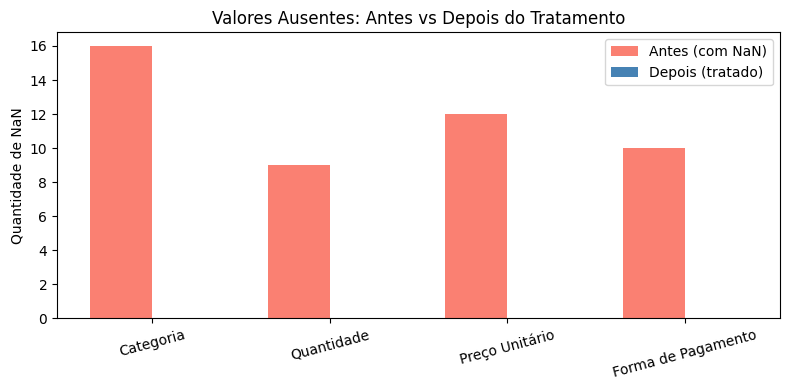

In [61]:
# Comparação visual: NaN antes vs depois do tratamento
nan_antes  = df_sujo.isnull().sum()
nan_depois = df_tratado.isnull().sum()

# Mostra apenas colunas que tinham NaN
cols_com_nan = nan_antes[nan_antes > 0].index.tolist()
fig, ax = plt.subplots(figsize=(8, 4))

x = range(len(cols_com_nan))
largura = 0.35
ax.bar([i - largura/2 for i in x], nan_antes[cols_com_nan], largura,
       label='Antes (com NaN)', color='salmon')
ax.bar([i + largura/2 for i in x], nan_depois[cols_com_nan], largura,
       label='Depois (tratado)', color='steelblue')

ax.set_xticks(list(x))
ax.set_xticklabels(cols_com_nan, rotation=15)
ax.set_title('Valores Ausentes: Antes vs Depois do Tratamento')
ax.set_ylabel('Quantidade de NaN')
ax.legend()
plt.tight_layout()
plt.show()

## Bloco 3 — Duplicatas:
Detectando e Removendo Registros Repetidos

O que são duplicatas? - Uma **duplicata** é um registro que aparece mais de uma vez na base.<br>
Causas comuns:
- Planilha foi importada duas vezes por engano
- Sistema registrou a mesma transação duas vezes
- Merge de duas bases com registros em comum

Em um sistema de vendas, uma duplicata pode significar que vendemos mais do que realmente vendemos — o que distorce faturamento, estoque e metas.

> `df.duplicated()` retorna uma Series boolean: `True` para linhas que já apareceram antes, `False` para a primeira ocorrência.

In [62]:
# duplicated() retorna True para a 2ª ocorrência em diante
duplicatas_mask = df_sujo.duplicated()
print(f"Total de duplicatas: {duplicatas_mask.sum()}")
print()

# Ver as linhas duplicadas
linhas_dup = df_sujo[duplicatas_mask].head(5)
print("Primeiras 5 linhas duplicadas:")
print(linhas_dup[['Data', 'Loja', 'Produto', 'Quantidade', 'Valor Líquido']].to_string())
print()

# Qual loja tem mais duplicatas?
dup_por_loja = df_sujo[duplicatas_mask]['Loja'].value_counts()
print("Duplicatas por loja:")
print(dup_por_loja.to_string())

Total de duplicatas: 12

Primeiras 5 linhas duplicadas:
          Data              Loja               Produto  Quantidade  Valor Líquido
62  2026-02-15       Loja Centro               Maçã kg         4.0          39.88
98  2026-01-12        Loja Norte     Leite Integral 1L         6.0          36.14
126 2026-02-04  Loja Bairro Alto  Linguiça Toscana 1kg         4.0          88.24
136 2026-03-27       Loja Centro             Batata kg         4.0          26.30
203 2026-03-14       Loja Centro             Batata kg         1.0           6.32

Duplicatas por loja:
Loja
Loja Centro         5
Loja Bairro Alto    3
Loja Norte          2
Loja Shopping       2


### Removendo Duplicatas com `drop_duplicates()`

`drop_duplicates()` remove as linhas duplicadas, mantendo a **primeira ocorrência** por padrão.

**Parâmetros úteis:**
- `keep='first'` (padrão) — mantém a primeira ocorrência
- `keep='last'`  — mantém a última ocorrência
- `keep=False`   — remove **todas** as cópias, incluindo a original
- `subset=['col1', 'col2']` — considera duplicata apenas se essas colunas forem iguais

In [65]:
# Remove todas as duplicatas (mantém primeira ocorrência)
df_sem_dup = df_sujo.drop_duplicates()

print(f"Antes : {len(df_sujo)} linhas")
print(f"Depois: {len(df_sem_dup)} linhas")
print(f"Removidas: {len(df_sujo) - len(df_sem_dup)} duplicatas")
print()

# Verificação: ainda há duplicatas?
print(f"Duplicatas restantes: {df_sem_dup.duplicated().sum()}")
print()

# keep=False remove TODAS as cópias (inclusive a original)
df_sem_qualquer_dup = df_sujo.drop_duplicates(keep=False)
print(f"Com keep=False: {len(df_sem_qualquer_dup)} linhas (remove original e cópia)")

Antes : 262 linhas
Depois: 250 linhas
Removidas: 12 duplicatas

Duplicatas restantes: 0

Com keep=False: 238 linhas (remove original e cópia)


## Pipeline completo - Tratar NaN e Duplicatas

In [66]:
# Este é o fluxo que usaremos na prática real
# Cria-se uma cópia do original (sempre)
df_limpo = df_sujo.copy()

# Passo 1: Remover duplicatas
df_limpo = df_limpo.drop_duplicates()
print(f"Após remover duplicatas: {len(df_limpo)} linhas")

# Passo 2: Preencher NaN categóricos com moda
df_limpo['Categoria']          = df_limpo['Categoria'].fillna(df_limpo['Categoria'].mode()[0])
df_limpo['Forma de Pagamento'] = df_limpo['Forma de Pagamento'].fillna(df_limpo['Forma de Pagamento'].mode()[0])

# Passo 3: Preencher NaN numéricos com mediana
df_limpo['Preço Unitário'] = df_limpo['Preço Unitário'].fillna(df_limpo['Preço Unitário'].median())
df_limpo['Quantidade']     = df_limpo['Quantidade'].fillna(df_limpo['Quantidade'].median()).astype(int)

# Verificação final
print(f"NaN restantes: {df_limpo.isnull().sum().sum()}")
print(f"Duplicatas restantes: {df_limpo.duplicated().sum()}")
print()
print(f"{'Base Original':<20} {df.shape[0]} linhas, {df.isnull().sum().sum()} NaN")
print(f"{'Base Suja':<20} {df_sujo.shape[0]} linhas, {df_sujo.isnull().sum().sum()} NaN")
print(f"{'Base Limpa':<20} {df_limpo.shape[0]} linhas, {df_limpo.isnull().sum().sum()} NaN")

Após remover duplicatas: 250 linhas
NaN restantes: 0
Duplicatas restantes: 0

Base Original        250 linhas, 0 NaN
Base Suja            262 linhas, 47 NaN
Base Limpa           250 linhas, 0 NaN


## Exercício Prático — Aula 01

Use o `df_sujo` criado nesta aula para responder:

1. Qual coluna tem o **maior percentual** de valores ausentes? Calcule e exiba.

2. Preencha os NaN da coluna `'Forma de Pagamento'` com o valor `'Pix'` (simula uma decisão de negócio: qualquer pagamento sem forma registrada foi via Pix). Confirme que não há mais NaN.

3. Para a coluna `'Preço Unitário'`, em vez da mediana, use a **média por Categoria** para preencher os NaN. Ou seja: cada produto deve ter seu NaN preenchido com a média dos outros produtos da mesma categoria. Dica: `groupby + transform('mean')`.

4. Verifique se existem duplicatas apenas considerando as colunas `['Data', 'Loja', 'Produto', 'Quantidade']` (ignora o restante). Quantas encontrou?

5. Crie um gráfico de pizza mostrando a distribuição de **Forma de Pagamento** após a limpeza completa.

## Gabarito — Pontos Principais

### Exercício 1 — Coluna com maior % de NaN
```python
pct = df_sujo.isnull().mean() * 100
print(pct.sort_values(ascending=False))
# Categoria tem ~5,5% (14/262 linhas)
```

### Exercício 3 — fillna com média por grupo
```python
media_por_cat = df_tratado.groupby('Categoria')['Preço Unitário'].transform('mean')
df_tratado['Preço Unitário'] = df_tratado['Preço Unitário'].fillna(media_por_cat)
```

### Exercício 4 — Duplicatas por subconjunto de colunas
```python
n = df_sujo.duplicated(subset=['Data','Loja','Produto','Quantidade']).sum()
print(f"Duplicatas (subset): {n}")
```

### Exercício 5 — Pizza de Forma de Pagamento
```python
pag = df_limpo['Forma de Pagamento'].value_counts()
plt.pie(pag.values, labels=pag.index, autopct='%1.1f%%')
plt.title('Distribuição de Forma de Pagamento')
plt.show()
```

## Observações Finais

Hoje você aprendeu:

- **Dados sujos são a regra**, não a exceção — a maioria das bases do mundo real tem problemas
- `isnull().sum()` → conta NaN por coluna
- `isnull().mean() * 100` → percentual de NaN (melhor para comparar)
- `fillna()` com moda para categorias, mediana para números
- `ffill()` / `bfill()` para dados temporais ordenados
- `duplicated()` detecta, `drop_duplicates()` remove
- **Nunca modifique a base original** — sempre trabalhe em `.copy()`

---
**Na próxima aula (quinta-feira):** vamos aprender a detectar e tratar *outliers* (valores extremos), normalizar dados e aplicar transformações nas colunas.